# Understanding Cross Entropy, Entropy and Loss Function in ML

1. [Training](#training) 
2. [Calculate Entropy for Predicted Test](#calculate-entropy-for-the-predicted-probability) 
3. [Calculate Cross Entropy for Predicted Test](#calculate-cross-entropy-for-each-image)
4. [Visual Analysis](#visual-analysis)
5. [Combined Results Analysis](#create-a-tabledata-frame-for-combined-analysis-of-the-results)
6. [Average Cross Entropy](#average-test-cross-entropy)


### Training  

In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical


c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [3]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Training Images:", x_train.shape)
print("Training Labels:", y_train.shape)

print("Test Images:", x_test.shape)
print("Test Labels:", y_test.shape)

Training Images: (60000, 28, 28)
Training Labels: (60000,)
Test Images: (10000, 28, 28)
Test Labels: (10000,)


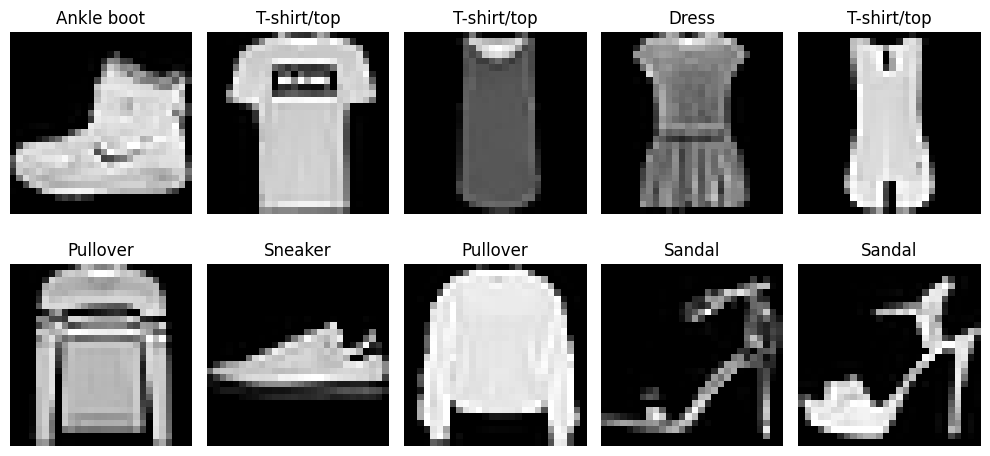

In [4]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat','Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [6]:
y_train_onehot = to_categorical(y_train, 10)
y_test_onehot = to_categorical(y_test, 10)

In [7]:
print(y_train[0])
print(y_train_onehot[0])

9
[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


In [8]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        10,
        activation="softmax"
    )
])

model.summary()

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

#### Cross entropy for bach or average batch loss and model training custom method

In [9]:
def custom_cross_entropy(y_true, y_pred):

    epsilon = 1e-10

    y_pred = tf.clip_by_value(
        y_pred,
        epsilon,
        1.0
    )

    loss = -tf.reduce_sum(
        y_true * tf.math.log(y_pred),
        axis=1
    )

    return tf.reduce_mean(loss)

In [10]:
model.compile(
    optimizer="adam",
    loss=custom_cross_entropy,
    metrics=["accuracy"]
)

In [11]:
history = model.fit(
    x_train,
    y_train_onehot,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.8153 - loss: 0.5269 - val_accuracy: 0.8100 - val_loss: 0.5125
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8596 - loss: 0.3941 - val_accuracy: 0.8625 - val_loss: 0.3804
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8729 - loss: 0.3545 - val_accuracy: 0.8622 - val_loss: 0.3755
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8811 - loss: 0.3280 - val_accuracy: 0.8755 - val_loss: 0.3331
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8859 - loss: 0.3093 - val_accuracy: 0.8792 - val_loss: 0.3365


In [12]:
test_loss, test_acc = model.evaluate(
    x_test,
    y_test_onehot
)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8702 - loss: 0.3610
Test Accuracy: 0.870199978351593
Test Loss: 0.3609844744205475


In [13]:
y_pred_probs = model.predict(x_test)

print(y_pred_probs.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
(10000, 10)


### Show that sum of predicted distribution comes to 1

In [58]:
sample = 0

print(y_pred_probs[sample])

print("sum:",
      np.sum(y_pred_probs[sample]))

[6.3854268e-06 9.8253520e-07 1.9805195e-06 8.0431312e-07 8.8158404e-06
 4.0721972e-02 4.0903301e-06 9.4442151e-02 1.3542523e-04 8.6467737e-01]
sum: 1.0


In [59]:
def entropy(probabilities):

    epsilon = 1e-10

    p = np.clip(
        probabilities,
        epsilon,
        1.0
    )

    return -np.sum(
        p * np.log(p)
    )

In [60]:
uniform = np.array([0.5, 0.5])

confident = np.array([0.99, 0.01])

print("Uniform:",
      entropy(uniform))

print("Confident:",
      entropy(confident))

Uniform: 0.6931471805599453
Confident: 0.056001534354847345


### calculate entropy for the predicted probability

In [61]:
entropies = []

for probs in y_pred_probs:
    entropies.append(
        entropy(probs)
    )

entropies = np.array(entropies)

print(entropies.shape)

(10000,)


### take the index of the max probability of each image and create new list and compare it to the test y index and assign the boolean to correct list

In [62]:
y_pred = np.argmax(
    y_pred_probs,
    axis=1
)

correct = (
    y_pred == y_test
)
print(correct[:50])

[ True  True  True  True  True  True  True  True  True  True  True  True
 False  True  True  True  True False  True  True  True  True  True False
  True False  True  True  True  True  True  True  True  True  True  True
  True  True  True  True False  True False  True  True  True  True  True
  True False]


### filter entropies where correct is true and assign to correct_entropy and to true to incorrect_entropy

In [63]:
correct_entropy = entropies[
    correct
]

incorrect_entropy = entropies[
    ~correct
]

In [64]:
print(
    "Average Entropy (Correct):",
    np.mean(correct_entropy)
)

print(
    "Average Entropy (Incorrect):",
    np.mean(incorrect_entropy)
)

Average Entropy (Correct): 0.25721356
Average Entropy (Incorrect): 0.8623874


In [65]:
def cross_entropy_sample(
        y_true,
        y_pred):

    epsilon = 1e-10

    y_pred = np.clip(
        y_pred,
        epsilon,
        1.0
    )

    return -np.sum(
        y_true * np.log(y_pred)
    )

### calculate cross entropy for each image

In [66]:
cross_entropies = []

for true_label, pred_prob in zip(
        y_test_onehot,
        y_pred_probs):

    loss = cross_entropy_sample(
        true_label,
        pred_prob
    )

    cross_entropies.append(loss)

cross_entropies = np.array(
    cross_entropies
)

### filter where it is correct and not correct

In [67]:
correct_ce = cross_entropies[
    correct
]

incorrect_ce = cross_entropies[
    ~correct
]

In [68]:
print(
    "Average CE (Correct):",
    np.mean(correct_ce)
)

print(
    "Average CE (Incorrect):",
    np.mean(incorrect_ce)
)

Average CE (Correct): 0.10949154558743757
Average CE (Incorrect): 2.0470334173901974


### Visual Analysis

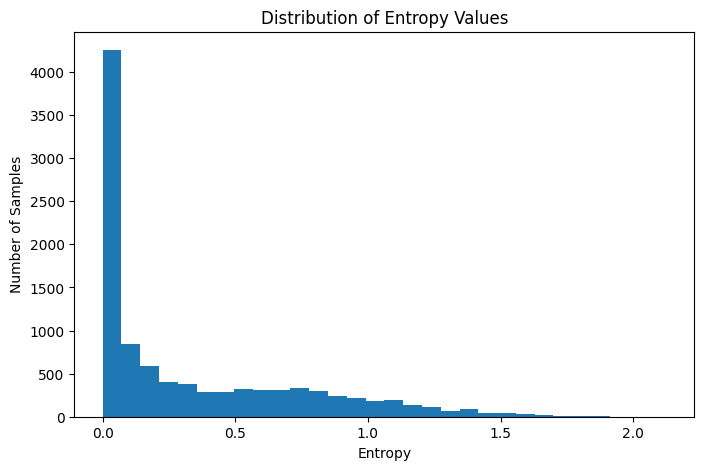

In [69]:
plt.figure(figsize=(8,5))

plt.hist(
    entropies,
    bins=30
)

plt.title("Distribution of Entropy Values")
plt.xlabel("Entropy")
plt.ylabel("Number of Samples")

plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_27148\815786963.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


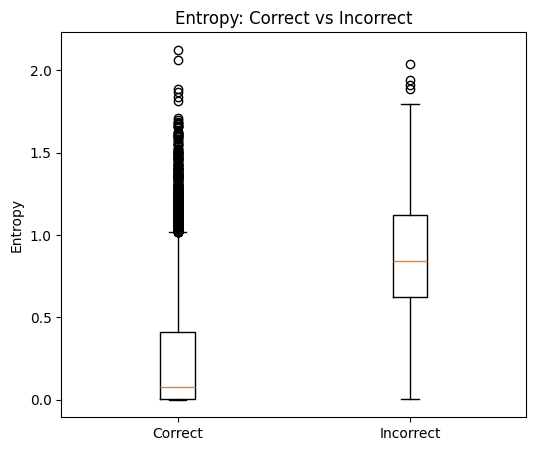

In [70]:
plt.figure(figsize=(6,5))

plt.boxplot([
    correct_entropy,
    incorrect_entropy
],
labels=[
    "Correct",
    "Incorrect"
])

plt.ylabel("Entropy")
plt.title("Entropy: Correct vs Incorrect")

plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_27148\1457827498.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


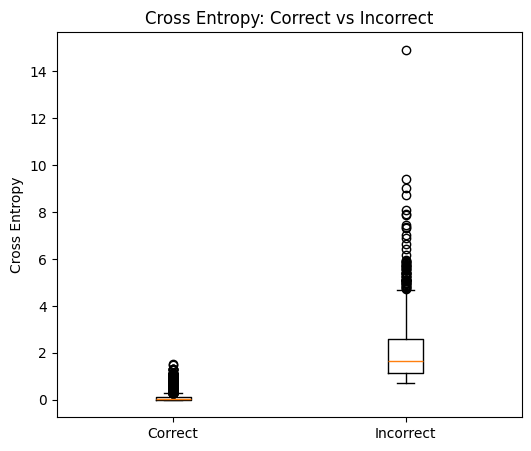

In [71]:
plt.figure(figsize=(6,5))

plt.boxplot([
    correct_ce,
    incorrect_ce
],
labels=[
    "Correct",
    "Incorrect"
])

plt.ylabel("Cross Entropy")
plt.title(
    "Cross Entropy: Correct vs Incorrect"
)

plt.show()

### Create a table/data frame for combined analysis of the results

In [72]:
import pandas as pd

results = pd.DataFrame({
    "true_label": y_test,
    "pred_label": y_pred,
    "correct": correct,
    "entropy": entropies,
    "cross_entropy": cross_entropies
})

results.head()

,true_label,pred_label,correct,entropy,cross_entropy
0,9,9,True,0.480422,0.145399
1,2,2,True,0.097422,0.016352
2,1,1,True,0.000052,0.000004
3,1,1,True,0.001152,0.000110
4,6,6,True,0.928404,0.403653


#### sort data by where entropy is higher

In [73]:
high_entropy = results.sort_values(
    by="entropy",
    ascending=False
)

high_entropy.head()

,true_label,pred_label,correct,entropy,cross_entropy
531,0,0,True,2.124425,1.531547
5023,0,0,True,2.059585,1.482053
9859,6,8,False,2.035546,2.779366
6452,6,0,False,1.938206,2.016938
1399,0,3,False,1.911078,1.581287


#### show images of the dataset where it was more uncertain

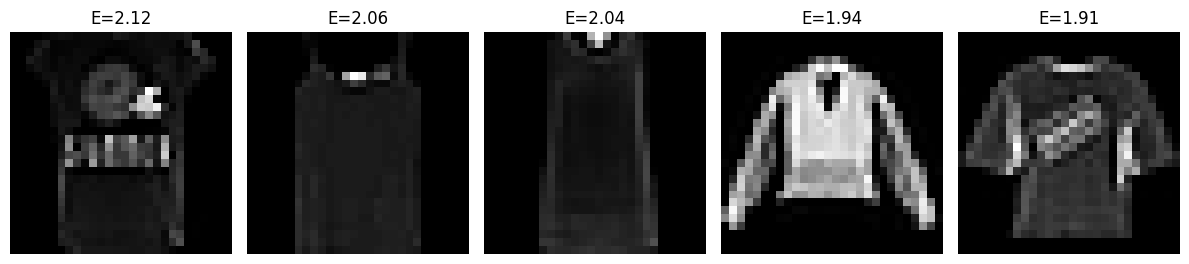

In [74]:
top_high = high_entropy.index[:5]

plt.figure(figsize=(12,4))

for i, idx in enumerate(top_high):

    plt.subplot(1,5,i+1)

    plt.imshow(
        x_test[idx],
        cmap="gray"
    )

    plt.title(
        f"E={entropies[idx]:.2f}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

#### Sort image by where entropy is small or it is confidence

In [75]:
low_entropy = results.sort_values(
    by="entropy",
    ascending=True
)

low_entropy.head()

,true_label,pred_label,correct,entropy,cross_entropy
1720,8,8,True,2.072326e-08,-0.0
7277,5,5,True,2.076399e-08,-0.0
8434,5,5,True,5.756913e-08,-0.0
3064,8,8,True,6.162056e-08,-0.0
484,5,5,True,1.152162e-07,-0.0


#### Show images of with the smallest entropy and confident prediction

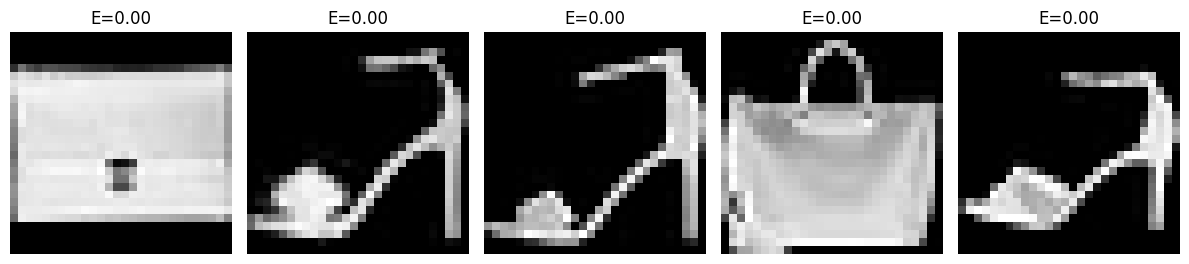

In [76]:
top_low = low_entropy.index[:5]

plt.figure(figsize=(12,4))

for i, idx in enumerate(top_low):

    plt.subplot(1,5,i+1)

    plt.imshow(
        x_test[idx],
        cmap="gray"
    )

    plt.title(
        f"E={entropies[idx]:.2f}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

#### Filter to get where prediction is not correct and sort it by where entropy is small which is confident but not correct 

In [77]:
confident_wrong = results[
    results["correct"] == False
]

confident_wrong = confident_wrong.sort_values(
    by="entropy"
)

confident_wrong.head()

,true_label,pred_label,correct,entropy,cross_entropy
787,1,3,False,0.005802,7.938085
3531,0,3,False,0.006012,9.409598
3262,6,4,False,0.015149,6.624149
2856,6,0,False,0.022920,5.785371
7936,9,7,False,0.025079,5.896424


#### show image of confident but not correct

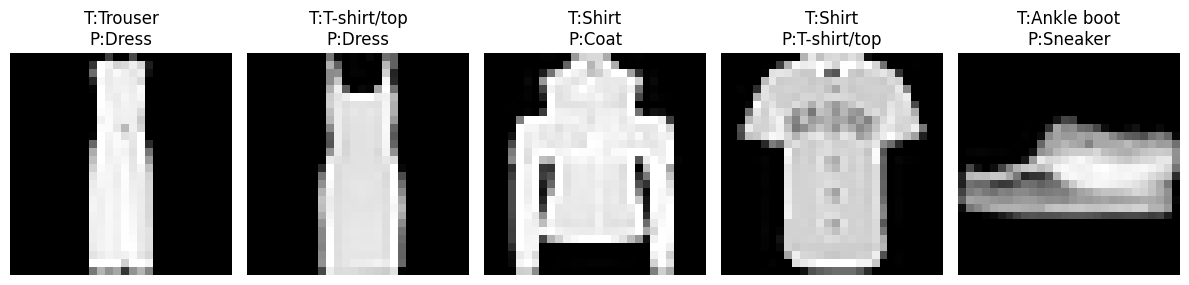

In [78]:
top_confident_wrong = confident_wrong.index[:5]

plt.figure(figsize=(12,4))

for i, idx in enumerate(top_confident_wrong):

    plt.subplot(1,5,i+1)

    plt.imshow(
        x_test[idx],
        cmap="gray"
    )

    true_name = class_names[
        y_test[idx]
    ]

    pred_name = class_names[
        y_pred[idx]
    ]

    plt.title(
        f"T:{true_name}\nP:{pred_name}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

### Average test cross entropy

In [79]:
average_ce = np.mean(
    cross_entropies
)

print(
    "Average Test Cross Entropy:",
    average_ce
)

Average Test Cross Entropy: 0.36098448054743576
